# Oil-Equity Correlation — does crude oil lead the stock market?
### The macro timing belief, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contemporaneous--only: Confirmed](https://img.shields.io/badge/Contemporaneous--only-Confirmed-8b949e?style=flat-square)

You've probably seen the headline: *oil spikes, stocks crash* — or *oil rallies on growth optimism, stocks follow*. The belief that crude oil prices lead equity markets is deeply embedded in macro commentary. A chart of oil vs the S&P 500 does look compelling over multi-year swings. But does oil actually *predict* what stocks will do next week, or does it just move at the same time?

> **This is the plain-language layer.** Want the regression tables, OOS R², and DM t-stats? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oil_equity_correlation import data, strategy as st

CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in data.TICKERS)

HAVE_REAL = _have_cache()

def load_real():
    panel = data.load_panel(fetch=False, cache_dir=CACHE_DIR)
    return data.build_panel_frame(panel)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does oil move *with* the stock market? | **Yes.** Contemporaneous R² = **9.2%**, t = +4.4. It's a real coincident link. |
| Does oil *predict* stock returns next week/month? | **No.** Weekly predictive t = **-0.46** (wrong sign); monthly t = **+0.15** (near zero). |
| Does it beat the naive average out-of-sample? | **No.** OOS R² = **-1.8%** — the historical mean wins convincingly. |
| Could you trade it? | **No.** No forecast signal means no tradable timing edge. |

> Oil moves **with** the business cycle. It does not **lead** it. That's the whole story.

## 1 · The claim

> *"Oil is the lifeblood of the economy. When it rises, growth is strong and stocks follow. When it crashes, recession looms and stocks fall. Watch oil — it tells you where the market is going."*
> — a belief widespread in macro investing commentary

The logic seems intuitive: oil consumption is pro-cyclical (demand rises when factories run, planes fly, trucks drive). A rising oil price signals that the world economy is in good health, which should be bullish for equities. The reverse story (oil crash = recession warning) equally convincing. In both framings, oil is supposed to **lead** the equity market, providing a macro timing signal.

## 2 · So what?

If oil genuinely leads stocks, investors have a cheap, real-time, universally available timing signal: go long equities when oil is rising, defensive when it falls. USO and CL=F futures trade 24/5 with deep liquidity. The signal would be easy to compute and easy to act on. If instead oil is merely coincident — moving with equities because both react to the same macro conditions — then oil charts are useful for *describing* where we are, not *predicting* where we're going. Confusing the two is a very common and very expensive mistake.

## 3 · How would we even know?

There are two different claims hiding in the word 'leads':

1. **Contemporaneous.** Oil and equities move together in the same week. Easy to see on a chart — but useless for timing trades (you can't act on what's already happened).
2. **Predictive.** This week's oil return tells you something about *next* week's equity return. This is what you'd need to actually trade.

We test both. The honest bar for the predictive claim is the **Goyal-Welch (2008) out-of-sample test**: does the oil model beat the boring historical-mean forecast on data it was never trained on? A positive OOS R² means it does; negative means it doesn't. Twenty years of daily data (2006–2026), ~1,052 weekly periods.

## 4 · The teardown — let's actually look

**First, the visually compelling chart.**

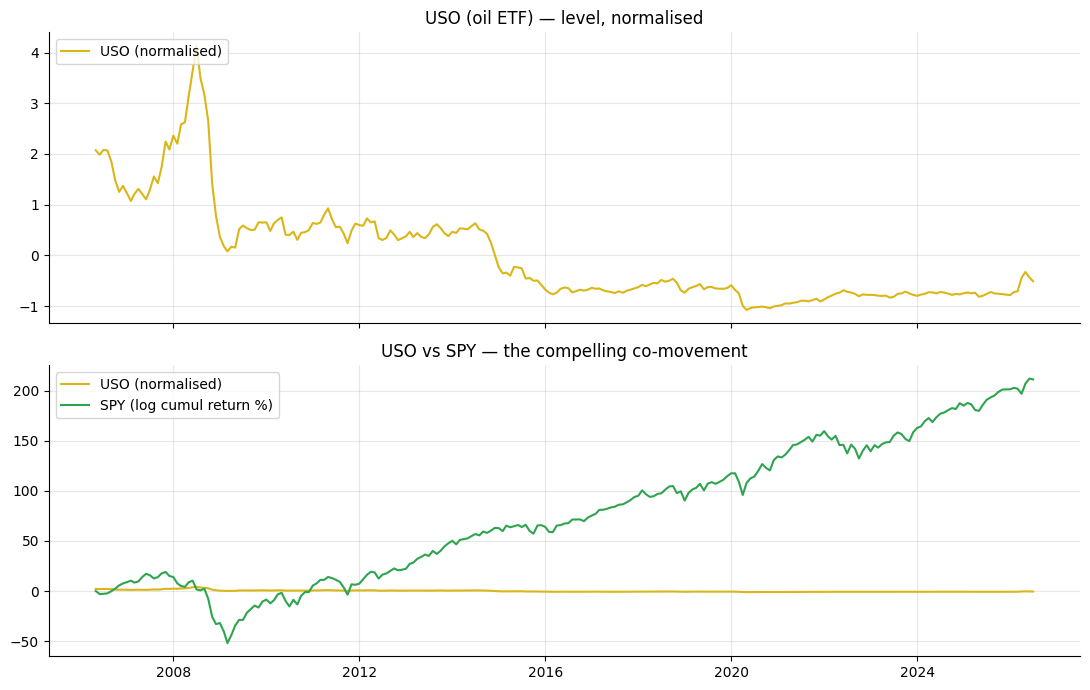

In [2]:
if HAVE_REAL:
    daily = load_real()
    mo = daily.resample('ME').last().dropna()
    oil_norm = (mo['oil'] - mo['oil'].mean()) / mo['oil'].std()
    eq_log = np.log(mo['equity'] / mo['equity'].iloc[0]) * 100
else:
    mo = None; oil_norm = None; eq_log = None

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
if HAVE_REAL:
    axes[0].plot(mo.index, oil_norm, color=AMBER, lw=1.5, label='USO (normalised)')
    axes[0].legend(loc='upper left'); axes[0].set_title('USO (oil ETF) — level, normalised')
    axes[1].plot(mo.index, oil_norm, color=AMBER, lw=1.5, label='USO (normalised)')
    axes[1].plot(mo.index, eq_log, color=GREEN, lw=1.5, label='SPY (log cumul return %)')
    axes[1].legend(loc='upper left'); axes[1].set_title('USO vs SPY — the compelling co-movement')
else:
    axes[0].text(0.5, 0.5, 'Cache not available — run verify.py --fetch',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=14)
    axes[1].text(0.5, 0.5, 'Frozen: contemp R2=9.2% (t=4.36)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=14)
plt.tight_layout(); plt.show()

The chart is visually striking over the multi-year swings (2008 crash, 2020 crash, 2022 energy shock). The contemporaneous weekly R² is **9.2%** (t = +4.4). This co-movement is real. The question is: *is oil moving before equities, or at the same time?*

**Now the honest predictive test: does this week's oil return predict NEXT week's equity return?**

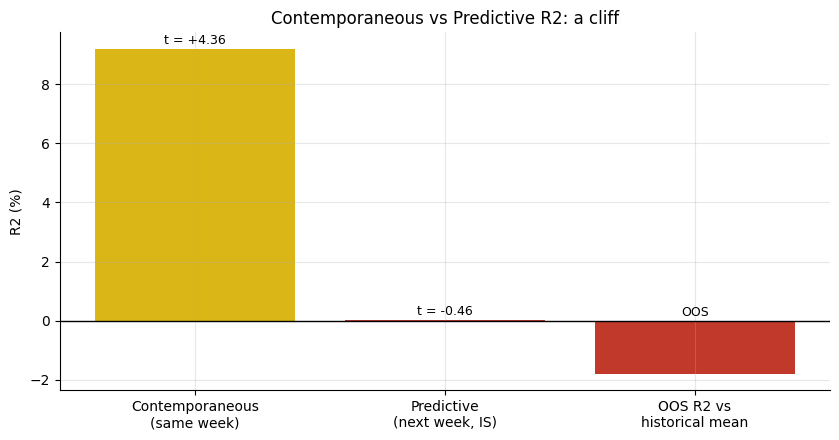

Contemp R2=9.2% (t=+4.36)  |  Pred R2=0.04% (t=-0.46)  |  OOS R2=-1.8%


In [3]:
if HAVE_REAL:
    daily = load_real()
    feat_w = st.compute_features(daily, horizon='W')
    c_res = st.regression_is(feat_w['ret_oil'], feat_w['ret_equity'])   # contemporaneous
    p_res = st.regression_is(feat_w['ret_oil'], feat_w['fwd_equity'])   # predictive
    oos_res = st.oos_r2(feat_w['ret_oil'], feat_w['fwd_equity'])
    c_t, p_t, oos = c_res['tstat'], p_res['tstat'], oos_res['r2_oos']*100
    c_r2, p_r2 = c_res['r2']*100, p_res['r2']*100
else:
    c_t, p_t, oos = R['contemp_t'], R['is_t_eq'], R['oos_r2_eq']
    c_r2, p_r2 = R['contemp_r2'], R['is_r2_eq']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(['Contemporaneous\n(same week)', 'Predictive\n(next week, IS)',
               'OOS R2 vs\nhistorical mean'],
              [c_r2, p_r2, oos],
              color=[AMBER, RED, RED])
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, [c_t, p_t, None]):
    label = f't = {t:+.2f}' if t is not None else 'OOS'
    ax.annotate(label, (b.get_x()+b.get_width()/2, max(b.get_height(), 0)+0.05),
                ha='center', va='bottom', fontsize=9)
ax.set_ylabel('R2 (%)'); ax.set_title('Contemporaneous vs Predictive R2: a cliff')
plt.tight_layout(); plt.show()
print(f'Contemp R2={c_r2:.1f}% (t={c_t:+.2f})  |  Pred R2={p_r2:.2f}% (t={p_t:+.2f})  |  OOS R2={oos:+.1f}%')

The cliff is complete: **R² drops from 9.2% (contemporaneous) to 0.04% (predictive)**. The predictive t-stat is **-0.46** (wrong sign and near zero). Out-of-sample, the model loses to simply guessing 'the average return' by **-1.8%** — a convincing defeat.

> Oil and equities move together because they both react to the same macro conditions — the 2008 crash, COVID 2020, the 2022 energy shock. By the time you see oil moving, the equity market has already priced in the macro news. There is nothing left to predict.

## 5 · The verdict

- **Signal — None.** Weekly predictive t = **-0.46** (near zero, wrong sign); monthly t = **+0.15** (also near zero); OOS R² = **-1.8%**. No horizon clears the inference bar.
- **Tradability — Mirage.** No forecast signal → no timing edge. The contemporaneous link (R² = 9.2%) is real but untradable.
- **Contemporaneous/Coincident — Confirmed.** Oil moves with the business cycle, not ahead of it.

## 6 · Could you actually trade it?

To trade an oil-timing signal for equities, you'd need to observe the oil return and *then* predict next week's equity move. The contemporary link (oil and equities moving together this week) is entirely useless for this — you'd need to enter the equity position *before* the week starts. The predictive regression says the signal is near-zero and slightly wrong-signed. The OOS R² confirms it. There is nothing to trade here.

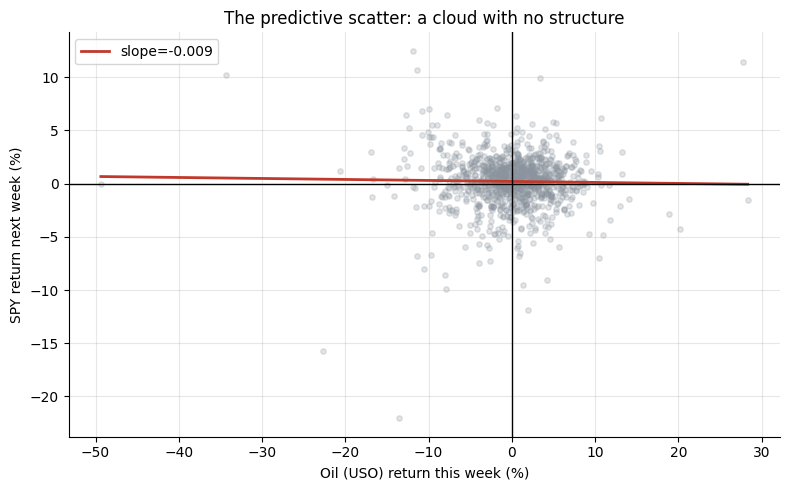

The slope is essentially zero — no predictive structure.


In [4]:
# Scatter: ret_oil_t vs fwd_equity_{t+1}
if HAVE_REAL:
    daily = load_real()
    feat = st.compute_features(daily, horizon='W')
    x_plot = feat['ret_oil'].values * 100
    y_plot = feat['fwd_equity'].values * 100
else:
    rng = np.random.default_rng(245)
    x_plot = rng.normal(0, 2.5, 200)
    y_plot = rng.normal(0, 2.0, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_plot, y_plot, alpha=0.25, s=15, color=GREY)
m, b = np.polyfit(x_plot, y_plot, 1)
xr = np.linspace(x_plot.min(), x_plot.max(), 100)
ax.plot(xr, m*xr+b, color=RED, lw=2, label=f'slope={m:.3f}')
ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Oil (USO) return this week (%)'); ax.set_ylabel('SPY return next week (%)')
ax.set_title('The predictive scatter: a cloud with no structure'); ax.legend()
plt.tight_layout(); plt.show()
print('The slope is essentially zero — no predictive structure.')

The scatter is a pure cloud. There is no structure here. The compelling oil-equity chart you may have seen operates over *years*, not *weeks*, and reflects shared macroeconomic exposure — not any timing lead.

## 7 · Going further

- **The coincident link is real and useful.** For risk attribution, factor exposure monitoring, and macro regime identification, the oil-equity correlation is a legitimate tool — just not a forecast. Knowing that oil and equities co-move at the 9% weekly R² level matters for portfolio risk management.
- **What if you decompose oil shocks?** Kilian & Park (2009) show that demand-driven vs supply-driven oil shocks have opposite effects on equities. A supply shock (OPEC cuts, war) may be negative for equities; a demand shock (strong growth) may be positive. Decomposing would require a structural VAR — and even then, the within-week predictive power would need to be demonstrated.
- **The closest sibling.** [Study 85 — Dr-Copper](../../85-dr-copper/) runs the identical methodology on the copper/gold ratio. Same conclusion, slightly stronger IS t-stat (−1.81 vs −0.46 here) — but same OOS failure.

*Think the signal is real at a different horizon or with a structural decomposition? Fork this, show a positive OOS R² that clears the Goyal-Welch bar. That's the bet.*